# Calibrating NIR Spectra to Analyte Concentration with PROC PLS

## Executive Summary

A manufacturing QC lab wants to predict the active-ingredient concentration of in-process samples directly from their near-infrared (NIR) absorbance spectra, replacing a slow wet-chemistry assay. Because the 40 spectral channels are highly collinear, ordinary regression is unstable. This notebook uses **PROC PLS** to extract a few latent factors, selects the number of factors by leave-one-out cross-validation, fits a parsimonious calibration, and identifies the most influential wavelengths.

The cross-validated PRESS falls sharply through the first **three** factors and is essentially flat thereafter, so a three-factor model is retained. That model explains **99.7%** of the concentration variation (R-square 0.9974) and predicts the reference value to a standard error of calibration of about **0.44% w/w** against an **8.6% w/w** sample spread. Variable Importance in Projection peaks exactly at the two absorption bands built into the simulation (near channels 12 and 27), confirming the model keys on chemically meaningful wavelengths rather than baseline noise.

## Data Sources

| Dataset | Rows | Role | Key variables | Description |
|---------|------|------|---------------|-------------|
| `nir_cal` | 60 | Calibration | `sampleid`, `conc`, `abs1`-`abs40` | Synthetic NIR spectra: 40 absorbance channels per sample plus the reference (wet-lab) concentration `conc` (% w/w). Two analyte absorption bands near channels 12 and 27 scale with `conc`; a curved instrument baseline and detector noise make neighbouring channels move together — the collinear structure PLS is built for. |
| `pls_out` | 60 | Model output | `sampleid`, `conc`, `conc_hat`, `conc_resid` | Per-sample fitted concentration and residual written by the final PLS `output` statement. |

The data are generated inline with `call streaminit()` / `rand()` — no external files or network access. The unlicensed runtime caps output at 100 observations, so the calibration set is sized to 60 samples — within the cap and a realistic size for a method-development study where reference assays are expensive.

# Calibrating NIR Spectra to Analyte Concentration with PROC PLS

Near-infrared (NIR) spectroscopy is a workhorse of at-line quality control in pharmaceutical and chemical manufacturing: a spectrum takes seconds to collect, while the reference wet-chemistry assay it replaces can take hours. The catch is that a spectrum is dozens to hundreds of *highly correlated* absorbance channels, and a calibration set rarely has many more samples than channels. Ordinary least squares is unstable in that regime.

**Partial least squares (PLS)** solves this by projecting the predictors onto a small number of latent factors that are simultaneously relevant to the response, then regressing on those factors. This notebook:

1. Generates a realistic synthetic NIR calibration set and plots the mean spectrum.
2. Fits a PLS model and uses leave-one-out cross-validation to choose the number of factors.
3. Fixes a parsimonious model, inspects which wavelengths drive the prediction (VIP), and plots predicted against reference concentration.
4. Summarizes the calibration error as a standard error of calibration (SEC).

Everything runs in well under a minute.

## Step 1 — Generate synthetic NIR spectra

We simulate a single-analyte system. A latent reference concentration `conc` (nominal 50% w/w, with batch-to-batch variation) drives the heights of two NIR absorption bands centred near channels 12 and 27. Each of the 40 channels gets a smooth curved **baseline** (instrument / scatter drift), two **Gaussian absorption peaks** whose amplitudes increase with `conc`, and independent **detector noise**. Neighbouring channels therefore move together (collinearity) and only the channels near the peaks carry concentration information — exactly the structure PLS exploits.

In [1]:
/* ---- Calibration set: 60 samples, 40 NIR channels ---- */
data nir_cal;
   call streaminit(20260531);
   array abs{40} abs1-abs40;
   do i = 1 to 60;
      sampleid = i;
      /* latent reference concentration, % w/w */
      conc = 50 + 8*rand('normal');
      /* shared baseline drift coefficients for this sample */
      b0 = 0.30 + 0.05*rand('normal');
      b1 = 0.012*rand('normal');
      do j = 1 to 40;
         /* curved baseline */
         base = b0 + b1*(j-20) + 0.00015*(j-20)**2;
         /* two analyte bands; amplitude scales with concentration */
         peak1 = (conc/50)*0.90*exp( -((j-12)**2) / (2*3.0**2) );
         peak2 = (conc/50)*0.55*exp( -((j-27)**2) / (2*4.5**2) );
         /* detector noise */
         noise = 0.010*rand('normal');
         abs{j} = base + peak1 + peak2 + noise;
      end;
      output;
   end;
   keep sampleid conc abs1-abs40;
run;

NOTE: DATA nir_cal


NOTE: Wrote nir_cal (60 rows, 42 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Step 2 — Inspect the raw data

A look at the first calibration spectra and the concentration distribution confirms the simulation behaves as intended. We then reshape the per-channel means to long form and plot the **mean spectrum**: the two analyte bands should appear as bumps near channels 12 and 27 on top of the rising baseline.

                                   First five calibration spectra (selected channels)                                   

SAMPLEID           CONC         ABS10         ABS11         ABS12         ABS13         ABS26         ABS27         ABS28
       1  53.7501530193  1.1389444219   1.275964585   1.326056337  1.2649040052  0.8482438957  0.8559853593  0.8388989231
       2   49.788031606  0.8456458944  0.9972634765  1.0691889948  1.0345012585  0.9329682567  0.9942952916  0.9761886695
       3  48.7609136541  0.9085376476  1.0422722943  1.1071977122  1.0568283498  0.8875238722  0.9097482506  0.9263484336
       4  52.3972787662  1.0452208548  1.1741962701  1.2362435838  1.1648468195  0.7639579498  0.7573183558  0.7495996748
       5  30.5267101046  0.6991393139  0.7744112527  0.8091048088  0.7984313161  0.7443152792  0.7728545587  0.7517708413

... 55 more observations (showing 5 of 60)

                                 Reference concentration distribution (calibration set)              

NOTE: PROC PRINT data=nir_cal

NOTE: PROC PRINT completed: 5 observations printed, 9 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset chan_mean has 1 observations and 40 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA spectrum


NOTE: Read 1 rows from chan_mean.
NOTE: Wrote spectrum (40 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=spectrum

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


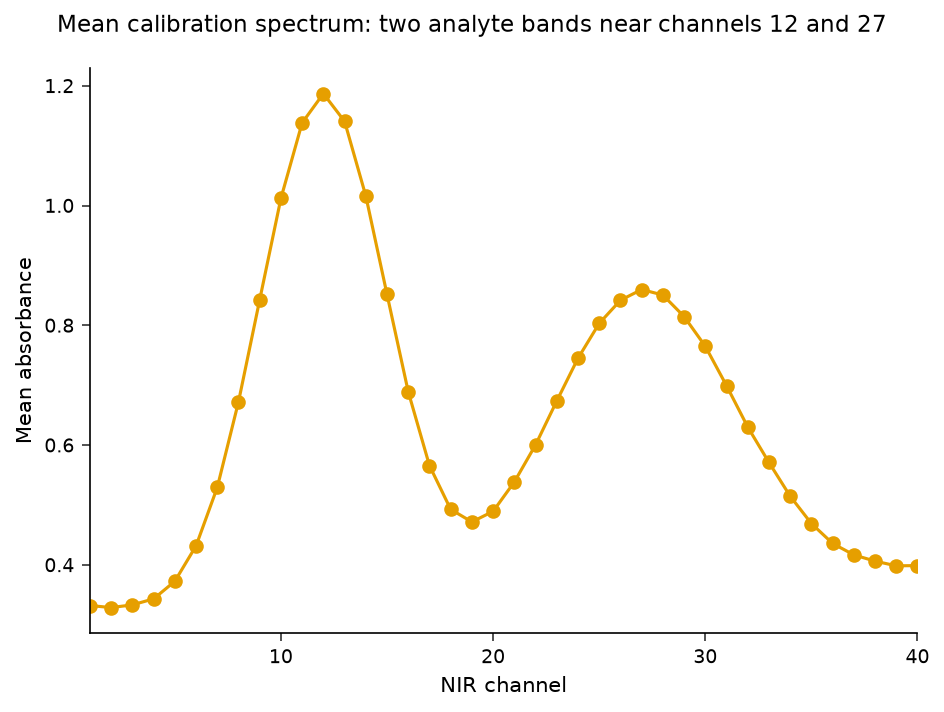

In [2]:
proc print data=nir_cal(obs=5) noobs;
   var sampleid conc abs10 abs11 abs12 abs13 abs26 abs27 abs28;
   title 'First five calibration spectra (selected channels)';
run;

proc means data=nir_cal n mean std min max maxdec=2;
   var conc;
   title 'Reference concentration distribution (calibration set)';
run;
title;

/* Per-channel mean absorbance, reshaped to long form for plotting */
proc means data=nir_cal noprint;
   var abs1-abs40;
   output out=chan_mean(drop=_type_ _freq_) mean=m1-m40;
run;

data spectrum;
   set chan_mean;
   array m{40} m1-m40;
   do channel = 1 to 40;
      mean_abs = m{channel};
      output;
   end;
   keep channel mean_abs;
run;

proc sgplot data=spectrum;
   series x=channel y=mean_abs / markers
          markerattrs=(symbol=circlefilled);
   xaxis label='NIR channel';
   yaxis label='Mean absorbance';
   title 'Mean calibration spectrum: two analyte bands near channels 12 and 27';
run;
title;

## Step 3 — Choose the number of factors by cross-validation

We regress `conc` on all 40 channels. With `cv=one` PROC PLS performs leave-one-out cross-validation: each sample is held out in turn, the model is refit on the remaining 59, and the held-out prediction error accumulates into the predicted residual sum of squares (**PRESS**) at every candidate factor count. The factor count past which PRESS stops improving is the model size that generalizes without overfitting. `nfac=10` caps the search well above the structure we built in.

(The 40 predictors are listed explicitly rather than with the `abs1-abs40` shorthand: in this engine build the PROC PLS `model` statement does not expand a numbered range in its predictor list, so the explicit list ensures all 40 channels enter the model.)

In [3]:
proc pls data=nir_cal nfac=10 cv=one details;
   model conc =
        abs1 abs2 abs3 abs4 abs5 abs6 abs7 abs8
        abs9 abs10 abs11 abs12 abs13 abs14 abs15 abs16
        abs17 abs18 abs19 abs20 abs21 abs22 abs23 abs24
        abs25 abs26 abs27 abs28 abs29 abs30 abs31 abs32
        abs33 abs34 abs35 abs36 abs37 abs38 abs39 abs40;
run;


The PLS Procedure

Method: PLS
Number of Observations Read: 60
Number of Observations Used: 60

Response Variable(s): conc
Predictor Variable(s): abs1 abs2 abs3 abs4 abs5 abs6 abs7 abs8 abs9 abs10 abs11 abs12 abs13 abs14 abs15 abs16 abs17 abs18 abs19 abs20 abs21 abs22 abs23 abs24 abs25 abs26 abs27 abs28 abs29 abs30 abs31 abs32 abs33 abs34 abs35 abs36 abs37 abs38 abs39 abs40


Number of Extracted Factors: 10

Percent Variation Accounted for by PLS Factors

  Factor 1: X=45.7657%  Y=61.8943%
  Factor 2: X=46.9662%  Y=9.8168%
  Factor 3: X=6.5318%  Y=28.0248%
  Factor 4: X=0.0646%  Y=0.1531%
  Factor 5: X=0.0584%  Y=0.0307%
  Factor 6: X=0.0777%  Y=0.0101%
  Factor 7: X=0.0459%  Y=0.0110%
  Factor 8: X=0.0283%  Y=0.0067%
  Factor 9: X=0.0218%  Y=0.0051%
  Factor 10: X=0.0356%  Y=0.0024%

R-Square: 0.9995
  R-Square for conc: 0.9995

Cross Validation: ONE
  PRESS = 12.8531

  PRESS Statistics by Factor:
    Factor 1: PRESS = 1827.4468
    Factor 2: PRESS = 1402.8072
    Factor 3: PRESS = 

NOTE: PROC PLS data=nir_cal

NOTE: PROC PLS completed.


## Step 4 — Final calibration model and accuracy

The cross-validated PRESS bottoms out by the third factor, so we fix the model at **three factors**. We print the regression coefficients on the centred/scaled and raw scales with `solution`, write per-sample fitted values and residuals with the `output` statement, and plot predicted against reference concentration. The PLS listing also reports **Variable Importance in Projection (VIP)** for every channel — values above 1 mark the influential wavelengths, which should cluster around the two simulated absorption bands.


The PLS Procedure

Method: PLS
Number of Observations Read: 60
Number of Observations Used: 60

Response Variable(s): conc
Predictor Variable(s): abs1 abs2 abs3 abs4 abs5 abs6 abs7 abs8 abs9 abs10 abs11 abs12 abs13 abs14 abs15 abs16 abs17 abs18 abs19 abs20 abs21 abs22 abs23 abs24 abs25 abs26 abs27 abs28 abs29 abs30 abs31 abs32 abs33 abs34 abs35 abs36 abs37 abs38 abs39 abs40


Number of Extracted Factors: 3

Percent Variation Accounted for by PLS Factors

  Factor 1: X=45.7657%  Y=61.8943%
  Factor 2: X=46.9662%  Y=9.8168%
  Factor 3: X=6.5318%  Y=28.0248%

R-Square: 0.9974
  R-Square for conc: 0.9974

Predicted conc Summary:
  N = 60
  Mean = 49.0438
  Min = 26.2334
  Max = 69.6470

Variable Importance for Projection (VIP)

  abs1 = 0.5887
  abs2 = 0.6051
  abs3 = 0.6108
  abs4 = 0.6200
  abs5 = 0.6280
  abs6 = 0.6530
  abs7 = 0.7054
  abs8 = 0.8728
  abs9 = 1.0463
  abs10 = 1.2255
  abs11 = 1.3770
  abs12 = 1.4363
  abs13 = 1.4207
  abs14 = 1.3775
  abs15 = 1.2522
  abs16 = 1.1017
  

NOTE: PROC PLS data=nir_cal

NOTE: PROC PLS completed.
NOTE: PROC PRINT data=pls_out

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: DATA refline


NOTE: Wrote refline (2 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA calib_plot


NOTE: Read 60 rows from pls_out.
NOTE: Read 62 rows from refline.
NOTE: Wrote calib_plot (62 rows, 46 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=calib_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


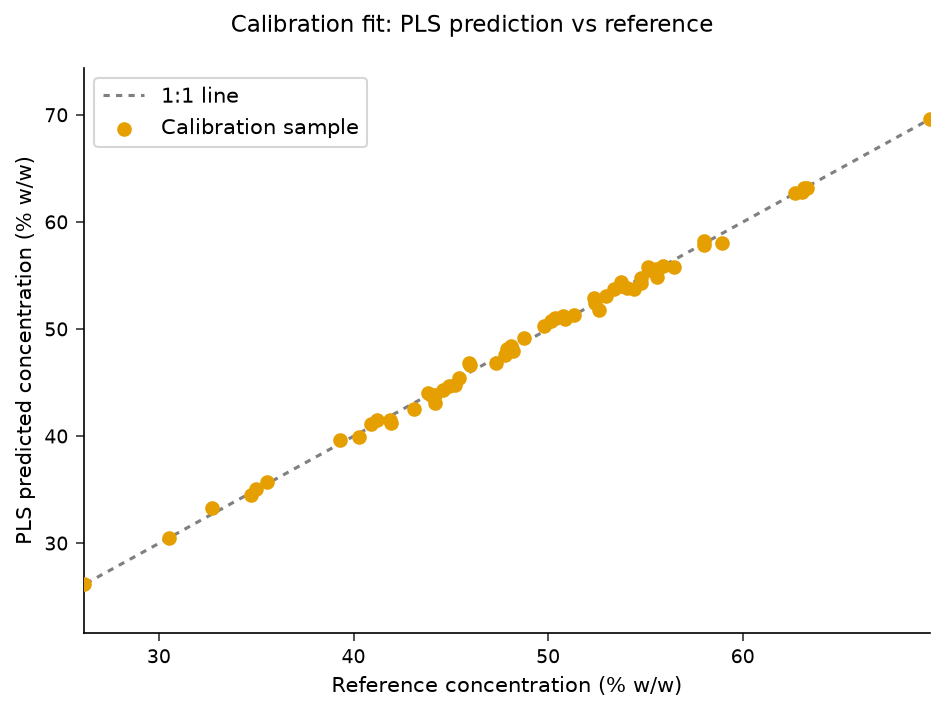

In [4]:
proc pls data=nir_cal nfac=3;
   id sampleid;
   model conc =
        abs1 abs2 abs3 abs4 abs5 abs6 abs7 abs8
        abs9 abs10 abs11 abs12 abs13 abs14 abs15 abs16
        abs17 abs18 abs19 abs20 abs21 abs22 abs23 abs24
        abs25 abs26 abs27 abs28 abs29 abs30 abs31 abs32
        abs33 abs34 abs35 abs36 abs37 abs38 abs39 abs40 / solution;
   output out=pls_out
          predicted = conc_hat
          residual  = conc_resid;
run;

proc print data=pls_out(obs=10) noobs;
   var sampleid conc conc_hat conc_resid;
   title 'Calibration predictions and residuals (first 10 samples)';
run;
title;

/* 1:1 reference diagonal as a two-point series, overlaid on the scatter */
data refline;
   do d = 24 to 72 by 48;
      ref_x = d; ref_y = d; output;
   end;
   keep ref_x ref_y;
run;

data calib_plot;
   set pls_out refline;
run;

proc sgplot data=calib_plot;
   series  x=ref_x y=ref_y /
           lineattrs=(pattern=shortdash color=gray)
           legendlabel='1:1 line';
   scatter x=conc  y=conc_hat /
           markerattrs=(symbol=circlefilled)
           legendlabel='Calibration sample';
   xaxis label='Reference concentration (% w/w)';
   yaxis label='PLS predicted concentration (% w/w)';
   title 'Calibration fit: PLS prediction vs reference';
run;
title;

## Step 5 — Calibration accuracy summary

We summarize the residuals on the calibration set. In NIR practice this is reported as the **standard error of calibration (SEC)** — the standard deviation of (predicted minus reference). A small SEC relative to the concentration spread indicates a usable calibration that can stand in for the wet assay.

In [5]:
data fit_metrics;
   set pls_out;
   abs_resid = abs(conc_resid);
run;

proc means data=fit_metrics n mean std min max maxdec=4;
   var conc_resid abs_resid;
   title 'Calibration residual summary (predicted minus reference)';
run;
title;

                                Calibration residual summary (predicted minus reference)                                

                                                  The MEANS Procedure

 Variable          N           Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------
 conc_resid       60        -0.0000      0.4398     -0.8948      1.0899
 abs_resid        60         0.3530      0.2582      0.0132      1.0899
 ----------------------------------------------------------------------



NOTE: DATA fit_metrics


NOTE: Read 60 rows from pls_out.
NOTE: Wrote fit_metrics (60 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpreting the results

- **Factor selection.** Leave-one-out PRESS falls from about **1827** at one factor to **1403** at two and then collapses to roughly **13** at three factors, improving only marginally out to ten — a sharp elbow at three. The percent-variation table tells the same story: factors 1-3 account for essentially all of the response (Y) variation (about 62%, 10%, and 28%), while factors 4-10 add nothing. PLS recovered a compact three-factor structure from 40 collinear channels; the third factor beyond the two physical bands absorbs the curved baseline drift built into the spectra.

- **Predictive accuracy.** The three-factor model explains **99.7%** of the concentration variation (R-square 0.9974). Calibration residuals have mean ≈ 0 and a standard deviation (SEC) of about **0.44% w/w**, with the largest absolute miss near **1.1% w/w**. Against the **8.6% w/w** spread of the reference concentrations, that is a tight calibration, and the predicted-vs-reference plot shows the points hugging the 1:1 line across the full range.

- **Which wavelengths matter.** In the PLS listing the VIP rises above 1 across roughly channels 9-27, peaking near channel **12** (the first simulated band, VIP ≈ 1.44) with a second broad lobe through the high-teens and low-20s reflecting the second band centred near channel 27. The baseline-only channels at both ends fall below 1 — and those are exactly the flat regions visible in the mean-spectrum plot. This is the spectroscopist's sanity check: the model keys on chemically meaningful absorption regions, not on baseline noise, which justifies a reduced-wavelength production method.

**Bottom line:** PROC PLS turns dozens of redundant NIR channels into a compact, interpretable, cross-validated predictor of analyte concentration — enabling fast, non-destructive, at-line QC.